# RELLIS-3D Vegetation-specific Fine-tuning Qualitative Comparison

Creates the paper figure with the same 4-column layout as the previous overall qualitative figure:

**Input | Ground Truth | Cross-dataset | Fine-tuned**

Rows:
1. Strong bush recovery
2. Mixed model response
3. Residual vegetation challenge

Vegetation errors:
- red: Bush → Ground
- orange: Tree → Ground
- blue: Grass → Non-ground

This notebook reuses saved per-image CSVs and prediction masks from the existing vegetation experiments, so it does not rerun model inference.

**FIXED version:** RGB and binary-GT paths are rebuilt from the currently extracted processed dataset, so stale `/content/...` paths stored in old CSV files are no longer used.

**v2 path fix:** `processed_name` is correctly treated as the saved prediction filename (`sequence + image stem`), not as the RGB filename. RGB and GT are now recovered through the exact `(sequence, stem)` mapping used by the original vegetation evaluation notebook.


In [1]:
from pathlib import Path
from collections import defaultdict
from io import BytesIO
import os
import re
import shutil
import zipfile

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

from google.colab import drive
drive.mount("/content/drive")

VEG_ROOT = Path("/content/drive/MyDrive/IRP/05_vegetation_evaluation")
CROSS_ROOT = VEG_ROOT / "02_rellis_cross_dataset"
FINETUNE_ROOT = VEG_ROOT / "03_rellis_finetuned"

CROSS_CSV = CROSS_ROOT / "rellis_cross_dataset_vegetation_per_image.csv"
FINETUNE_CSV = FINETUNE_ROOT / "rellis_finetuned_vegetation_per_image.csv"

CROSS_PRED_ROOT = CROSS_ROOT / "predictions"
FINETUNE_PRED_ROOT = FINETUNE_ROOT / "predictions"

RAW_RELLIS_ZIP = Path("/content/drive/MyDrive/IRP/01_data/raw/RELLIS-3D.zip")
PROCESSED_RELLIS_ZIP = Path(
    "/content/drive/MyDrive/IRP/01_data/processed/RELLIS_3D_binary_processed.zip"
)

OUTPUT_DIR = FINETUNE_ROOT / "qualitative_before_after"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_PATH = OUTPUT_DIR / "rellis3d_vegetation_finetuning_qualitative.png"
SELECTED_CASES_CSV = OUTPUT_DIR / "selected_vegetation_qualitative_cases.csv"

NON_GROUND_ID = 0
GROUND_ID = 1
IGNORE_INDEX = 255
IGNORE_COLOUR = np.array([140, 140, 140], dtype=np.uint8)

MODEL_ORDER = ["U-Net", "DeepLabV3+", "SegFormer-B0", "ROD"]
MIN_BUSH_PIXELS = 500

for path in [CROSS_CSV, FINETUNE_CSV, RAW_RELLIS_ZIP, PROCESSED_RELLIS_ZIP]:
    if not path.exists():
        raise FileNotFoundError(f"Required file not found: {path}")

print("Cross-dataset CSV:", CROSS_CSV)
print("Fine-tuned CSV   :", FINETUNE_CSV)
print("Output figure    :", FIG_PATH)


Mounted at /content/drive
Cross-dataset CSV: /content/drive/MyDrive/IRP/05_vegetation_evaluation/02_rellis_cross_dataset/rellis_cross_dataset_vegetation_per_image.csv
Fine-tuned CSV   : /content/drive/MyDrive/IRP/05_vegetation_evaluation/03_rellis_finetuned/rellis_finetuned_vegetation_per_image.csv
Output figure    : /content/drive/MyDrive/IRP/05_vegetation_evaluation/03_rellis_finetuned/qualitative_before_after/rellis3d_vegetation_finetuning_qualitative.png


In [2]:
before = pd.read_csv(CROSS_CSV)
after = pd.read_csv(FINETUNE_CSV)

required = [
    "model",
    "processed_name",
    "sequence",
    "stem",
    "image_path",
    "binary_mask_path",
    "source_semantic_mask",
    "bush_pixels",
    "grass_ground_recall",
    "tree_non_ground_recall",
    "bush_non_ground_recall",
    "bush_ground_leakage",
]

for name, df in [("cross-dataset", before), ("fine-tuned", after)]:
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"{name} CSV is missing required columns: {missing}")

before_small = before[required].copy()
after_small = after[required].copy()

before_small = before_small.rename(
    columns={c: f"{c}_before" for c in required if c not in ["model", "processed_name", "sequence", "stem"]}
)
after_small = after_small.rename(
    columns={c: f"{c}_after" for c in required if c not in ["model", "processed_name", "sequence", "stem"]}
)

paired = before_small.merge(
    after_small,
    on=["model", "processed_name", "sequence", "stem"],
    how="inner",
    validate="one_to_one",
)

paired = paired[
    (paired["bush_pixels_before"] >= MIN_BUSH_PIXELS)
    & (paired["bush_pixels_after"] >= MIN_BUSH_PIXELS)
].copy()

paired["delta_bush_recall"] = (
    paired["bush_non_ground_recall_after"]
    - paired["bush_non_ground_recall_before"]
)
paired["leakage_reduction"] = (
    paired["bush_ground_leakage_before"]
    - paired["bush_ground_leakage_after"]
)
paired["delta_grass_recall"] = (
    paired["grass_ground_recall_after"]
    - paired["grass_ground_recall_before"]
)
paired["delta_tree_recall"] = (
    paired["tree_non_ground_recall_after"]
    - paired["tree_non_ground_recall_before"]
)

paired["model"] = pd.Categorical(
    paired["model"],
    categories=MODEL_ORDER,
    ordered=True,
)

print(f"Comparable model-scene pairs: {len(paired)}")
print(f"Unique scenes: {paired['processed_name'].nunique()}")

display(
    paired[
        [
            "model",
            "processed_name",
            "bush_non_ground_recall_before",
            "bush_non_ground_recall_after",
            "delta_bush_recall",
            "bush_ground_leakage_before",
            "bush_ground_leakage_after",
            "leakage_reduction",
        ]
    ].head()
)


Comparable model-scene pairs: 3596
Unique scenes: 899


,model,processed_name,bush_non_ground_recall_before,bush_non_ground_recall_after,delta_bush_recall,bush_ground_leakage_before,bush_ground_leakage_after,leakage_reduction
0,U-Net,00004_Rellis-3D__00004__pylon_camera_node__fra...,0.992231,0.992721,0.000490,0.007769,0.007279,0.000490
1,U-Net,00004_Rellis-3D__00004__pylon_camera_node__fra...,0.968396,0.962824,-0.005572,0.031604,0.037176,-0.005572
2,U-Net,00004_Rellis-3D__00004__pylon_camera_node__fra...,0.963366,0.974599,0.011232,0.036634,0.025401,0.011232
3,U-Net,00004_Rellis-3D__00004__pylon_camera_node__fra...,0.985011,0.991385,0.006374,0.014989,0.008615,0.006374
4,U-Net,00004_Rellis-3D__00004__pylon_camera_node__fra...,0.974263,0.979021,0.004759,0.025737,0.020979,0.004759


In [26]:
selected_rows = []
used_scenes = set()

def choose_first(candidates, label):
    candidates = candidates[
        ~candidates["processed_name"].isin(used_scenes)
    ].copy()

    if len(candidates) == 0:
        raise RuntimeError(f"No unused candidate available for: {label}")

    row = candidates.iloc[0].copy()
    row["case_name"] = label

    selected_rows.append(row)
    used_scenes.add(row["processed_name"])


# 1) Strong bush recovery
strong_candidates = paired[
    paired["bush_non_ground_recall_after"] >= 0.70
].sort_values(
    ["delta_bush_recall", "leakage_reduction", "bush_pixels_after"],
    ascending=[False, False, False],
)

if len(strong_candidates) == 0:
    strong_candidates = paired.sort_values(
        "delta_bush_recall",
        ascending=False,
    )

choose_first(strong_candidates, "Strong recovery")


# 2) Mixed model response:
# Prefer a genuine scene-level degradation after fine-tuning.
mixed_candidates = paired[
    paired["delta_bush_recall"] < 0
].sort_values(
    "delta_bush_recall",
    ascending=True,
)

if len(
    mixed_candidates[
        ~mixed_candidates["processed_name"].isin(used_scenes)
    ]
) == 0:
    mixed_candidates = paired.sort_values(
        ["delta_bush_recall", "leakage_reduction"],
        ascending=[True, True],
    )

choose_first(mixed_candidates, "Mixed response")


# 3) Residual vegetation challenge
residual_candidates = paired[
    (paired["model"].astype(str) == "ROD")
    & (paired["bush_non_ground_recall_after"] >= 0.15)
    & (paired["bush_non_ground_recall_after"] <= 0.75)
].sort_values(
    [
        "bush_non_ground_recall_after",
        "bush_pixels_after",
    ],
    ascending=[True, False],
)

if len(
    residual_candidates[
        ~residual_candidates["processed_name"].isin(used_scenes)
    ]
) == 0:
    residual_candidates = paired.sort_values(
        "bush_non_ground_recall_after",
        ascending=True,
    )

choose_first(residual_candidates, "Limited recovery")

selected = pd.DataFrame(selected_rows).reset_index(drop=True)
selected.to_csv(SELECTED_CASES_CSV, index=False)

display(
    selected[
        [
            "case_name",
            "model",
            "processed_name",
            "bush_pixels_after",
            "bush_non_ground_recall_before",
            "bush_non_ground_recall_after",
            "delta_bush_recall",
            "bush_ground_leakage_before",
            "bush_ground_leakage_after",
            "leakage_reduction",
        ]
    ]
)

print("Saved selection table:", SELECTED_CASES_CSV)


,case_name,model,processed_name,bush_pixels_after,bush_non_ground_recall_before,bush_non_ground_recall_after,delta_bush_recall,bush_ground_leakage_before,bush_ground_leakage_after,leakage_reduction
0,Strong recovery,DeepLabV3+,00004_Rellis-3D__00004__pylon_camera_node__fra...,451873,0.261040,0.996937,0.735897,0.738960,0.003063,0.735897
1,Mixed response,U-Net,00004_Rellis-3D__00004__pylon_camera_node__fra...,323246,0.955121,0.730243,-0.224878,0.044879,0.269757,-0.224878
2,Limited recovery,ROD,00004_Rellis-3D__00004__pylon_camera_node__fra...,199666,0.698972,0.723118,0.024145,0.301028,0.276882,0.024145


Saved selection table: /content/drive/MyDrive/IRP/05_vegetation_evaluation/03_rellis_finetuned/qualitative_before_after/selected_vegetation_qualitative_cases.csv


In [4]:
WORK_ROOT = Path("/content/rellis_vegetation_qualitative_compare")
WORK_ROOT.mkdir(parents=True, exist_ok=True)

INNER_LABEL_ZIP_PATH = (
    WORK_ROOT / "Rellis_3D_pylon_camera_node_label_color.zip"
)

if not INNER_LABEL_ZIP_PATH.exists():
    with zipfile.ZipFile(RAW_RELLIS_ZIP, "r") as outer:
        candidates = [
            member
            for member in outer.namelist()
            if Path(member).name == "Rellis_3D_pylon_camera_node_label_color.zip"
        ]

        if not candidates:
            raise FileNotFoundError(
                "Rellis_3D_pylon_camera_node_label_color.zip "
                "was not found inside RELLIS-3D.zip"
            )

        with outer.open(candidates[0], "r") as source:
            with open(INNER_LABEL_ZIP_PATH, "wb") as target:
                shutil.copyfileobj(source, target)

raw_label_zip = zipfile.ZipFile(INNER_LABEL_ZIP_PATH, "r")
raw_members = raw_label_zip.namelist()

def normalise_zip_path(path_value):
    return (
        str(path_value)
        .replace("\\", "/")
        .strip()
        .lstrip("./")
        .lstrip("/")
    )

normalised_to_member = {
    normalise_zip_path(member): member
    for member in raw_members
}

suffix_lookup = defaultdict(list)
filename_lookup = defaultdict(list)

for member in raw_members:
    norm = normalise_zip_path(member)

    if norm.endswith("/"):
        continue

    parts = norm.split("/")
    filename_lookup[parts[-1]].append(member)

    for depth in range(2, min(8, len(parts)) + 1):
        suffix_lookup["/".join(parts[-depth:])].append(member)

def resolve_raw_member(path_value):
    target = normalise_zip_path(path_value)

    if target in normalised_to_member:
        return normalised_to_member[target]

    possible_targets = [target]

    for prefix in ["Rellis-3D/", "RELLIS-3D/"]:
        if target.startswith(prefix):
            possible_targets.append(target[len(prefix):])

    for candidate in possible_targets:
        if candidate in normalised_to_member:
            return normalised_to_member[candidate]

    for candidate in possible_targets:
        parts = candidate.split("/")

        for depth in range(min(8, len(parts)), 1, -1):
            suffix = "/".join(parts[-depth:])
            matches = suffix_lookup.get(suffix, [])

            if len(matches) == 1:
                return matches[0]

    filename = target.split("/")[-1]
    matches = filename_lookup.get(filename, [])

    if len(matches) == 1:
        return matches[0]

    return None

def read_raw_semantic_label(source_mask_path):
    member = resolve_raw_member(source_mask_path)

    if member is None:
        raise FileNotFoundError(
            "Cannot resolve raw RELLIS semantic label: "
            f"{source_mask_path}"
        )

    with raw_label_zip.open(member, "r") as source:
        semantic_rgb = np.array(
            Image.open(BytesIO(source.read())).convert("RGB")
        )

    return semantic_rgb


In [5]:
# 4b. Re-extract processed RELLIS-3D and rebuild CURRENT valid paths
#
# IMPORTANT:
# `processed_name` is NOT the RGB filename.
#
# In the original vegetation evaluation notebook it is created as:
#
#     processed_name = f"{sequence_norm}_{image_stem}.png"
#
# It is the filename of the SAVED PREDICTION.
#
# Therefore, RGB/GT must be mapped back using the original
# (sequence, stem) pair, exactly as done by the old evaluation code.

PROCESSED_EXTRACT_DIR = WORK_ROOT / "processed"
PROCESSED_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)


def find_file_recursively(root: Path, filename: str):
    matches = list(Path(root).rglob(filename))
    return matches[0] if matches else None


MANIFEST_PATH = find_file_recursively(
    PROCESSED_EXTRACT_DIR,
    "manifest.csv",
)

if MANIFEST_PATH is None:
    print("Extracting processed RELLIS-3D archive...")

    with zipfile.ZipFile(PROCESSED_RELLIS_ZIP, "r") as archive:
        archive.extractall(PROCESSED_EXTRACT_DIR)

    MANIFEST_PATH = find_file_recursively(
        PROCESSED_EXTRACT_DIR,
        "manifest.csv",
    )

if MANIFEST_PATH is None:
    raise FileNotFoundError(
        "manifest.csv was not found after extracting "
        "RELLIS_3D_binary_processed.zip"
    )

DATA_ROOT = MANIFEST_PATH.parent

print("Current DATA_ROOT:", DATA_ROOT)
print("Current manifest :", MANIFEST_PATH)

manifest_df = pd.read_csv(MANIFEST_PATH)


def resolve_column(dataframe, candidates, required=True):
    for column in candidates:
        if column in dataframe.columns:
            return column

    if required:
        raise KeyError(
            f"Cannot resolve column from {candidates}; "
            f"available={dataframe.columns.tolist()}"
        )

    return None


split_col = resolve_column(
    manifest_df,
    ["split", "subset", "partition"],
)

image_col = resolve_column(
    manifest_df,
    ["processed_image", "image_path", "image", "image_file"],
)

mask_col = resolve_column(
    manifest_df,
    ["processed_mask", "mask_path", "mask", "label_path", "binary_mask"],
)

sequence_col = resolve_column(
    manifest_df,
    ["sequence", "sequence_id", "seq"],
)

source_mask_col_manifest = resolve_column(
    manifest_df,
    ["source_mask", "original_mask", "source_label", "semantic_mask"],
    required=False,
)


def normalise_sequence(value):
    text = str(value).strip()

    if re.fullmatch(r"\d+(\.0)?", text):
        return f"{int(float(text)):05d}"

    return text


def resolve_processed_path(value):
    path = Path(str(value))

    if path.is_absolute() and path.exists():
        return str(path)

    candidate = DATA_ROOT / path
    if candidate.exists():
        return str(candidate)

    path_text = str(path).replace("\\", "/")
    parts = [part for part in path_text.split("/") if part]

    for depth in range(min(6, len(parts)), 0, -1):
        suffix = Path(*parts[-depth:])
        candidate = DATA_ROOT / suffix

        if candidate.exists():
            return str(candidate)

    matches = list(DATA_ROOT.rglob(path.name))

    if len(matches) == 1:
        return str(matches[0])

    # Match the behaviour of the original notebook: keep the candidate
    # so the later explicit missing-file check gives a useful error.
    return str(DATA_ROOT / path)


work_df = manifest_df.copy()

work_df["split_norm"] = (
    work_df[split_col]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "validation": "val",
        "valid": "val",
        "testing": "test",
    })
)

work_df["sequence_norm"] = (
    work_df[sequence_col]
    .map(normalise_sequence)
)

work_df["image_path_resolved"] = (
    work_df[image_col]
    .map(resolve_processed_path)
)

work_df["mask_path_resolved"] = (
    work_df[mask_col]
    .map(resolve_processed_path)
)

# This is exactly how the original vegetation notebook generated "stem".
work_df["stem"] = (
    work_df["image_path_resolved"]
    .map(lambda path: Path(path).stem)
)

test_manifest_df = (
    work_df[
        work_df["split_norm"] == "test"
    ]
    .reset_index(drop=True)
)

missing = test_manifest_df[
    ~test_manifest_df["image_path_resolved"].map(os.path.exists)
    |
    ~test_manifest_df["mask_path_resolved"].map(os.path.exists)
]

if len(missing):
    display(
        missing[
            [
                image_col,
                mask_col,
                "image_path_resolved",
                "mask_path_resolved",
            ]
        ].head(20)
    )

    raise FileNotFoundError(
        f"{len(missing)} RELLIS test rows contain missing files."
    )


# Unique lookup by exactly the same identifiers saved in the per-image CSV.
manifest_lookup = {}

for _, manifest_row in test_manifest_df.iterrows():
    key = (
        str(manifest_row["sequence_norm"]),
        str(manifest_row["stem"]),
    )

    if key in manifest_lookup:
        raise RuntimeError(
            f"Duplicate (sequence, stem) key in manifest: {key}"
        )

    manifest_lookup[key] = manifest_row


print("Test manifest rows:", len(test_manifest_df))
print("Unique (sequence, stem) keys:", len(manifest_lookup))

# Sanity-check the first selected row.
if len(selected):
    check_key = (
        normalise_sequence(selected.iloc[0]["sequence"]),
        str(selected.iloc[0]["stem"]),
    )

    print("Example selected key:", check_key)
    print("Found in manifest:", check_key in manifest_lookup)

    # Also explain why processed_name itself must NOT be searched as RGB filename.
    print(
        "Example processed_name (prediction filename):",
        selected.iloc[0]["processed_name"],
    )


Extracting processed RELLIS-3D archive...
Current DATA_ROOT: /content/rellis_vegetation_qualitative_compare/processed/RELLIS_3D_binary_processed
Current manifest : /content/rellis_vegetation_qualitative_compare/processed/RELLIS_3D_binary_processed/manifest.csv
Test manifest rows: 899
Unique (sequence, stem) keys: 899
Example selected key: ('00004', 'Rellis-3D__00004__pylon_camera_node__frame001304-1581791808_808')
Found in manifest: True
Example processed_name (prediction filename): 00004_Rellis-3D__00004__pylon_camera_node__frame001304-1581791808_808.png


In [6]:
MAPPING_WORK_DIR = WORK_ROOT / "processed_mapping"
MAPPING_WORK_DIR.mkdir(parents=True, exist_ok=True)

mapping_candidates = list(
    MAPPING_WORK_DIR.rglob("binary_label_mapping.csv")
)

if not mapping_candidates:
    with zipfile.ZipFile(PROCESSED_RELLIS_ZIP, "r") as archive:
        members = [
            m for m in archive.namelist()
            if Path(m).name == "binary_label_mapping.csv"
        ]

        if not members:
            raise FileNotFoundError(
                "binary_label_mapping.csv was not found in "
                "RELLIS_3D_binary_processed.zip"
            )

        archive.extract(members[0], MAPPING_WORK_DIR)

    mapping_candidates = list(
        MAPPING_WORK_DIR.rglob("binary_label_mapping.csv")
    )

mapping_df = pd.read_csv(mapping_candidates[0])

def parse_rgb(value):
    numbers = re.findall(r"\d+", str(value))

    if len(numbers) != 3:
        raise ValueError(f"Cannot parse RGB value: {value}")

    return tuple(int(x) for x in numbers)

mapping_df["class_name_norm"] = (
    mapping_df["class_name"]
    .astype(str)
    .str.strip()
    .str.lower()
)

mapping_df["rgb_tuple"] = mapping_df["rgb"].map(parse_rgb)

def class_rgb(class_name):
    rows = mapping_df[
        mapping_df["class_name_norm"] == class_name.lower()
    ]

    if len(rows) != 1:
        raise ValueError(
            f"Expected exactly one mapping row for "
            f"{class_name}; found {len(rows)}"
        )

    return np.asarray(
        rows.iloc[0]["rgb_tuple"],
        dtype=np.uint8,
    )

GRASS_RGB = class_rgb("grass")
TREE_RGB = class_rgb("tree")
BUSH_RGB = class_rgb("bush")

print("Grass RGB:", GRASS_RGB.tolist())
print("Tree RGB :", TREE_RGB.tolist())
print("Bush RGB :", BUSH_RGB.tolist())

def binary_region_from_rgb(semantic_rgb, colour):
    return np.all(
        semantic_rgb == colour[None, None, :],
        axis=-1,
    )

def extract_vegetation_regions(semantic_rgb):
    return {
        "grass": binary_region_from_rgb(semantic_rgb, GRASS_RGB),
        "tree": binary_region_from_rgb(semantic_rgb, TREE_RGB),
        "bush": binary_region_from_rgb(semantic_rgb, BUSH_RGB),
    }

def load_binary_mask(path):
    mask = np.array(Image.open(path))

    if mask.ndim == 3:
        if (
            np.array_equal(mask[..., 0], mask[..., 1])
            and np.array_equal(mask[..., 0], mask[..., 2])
        ):
            mask = mask[..., 0]
        else:
            raise ValueError(f"Expected grayscale binary mask: {path}")

    return mask.astype(np.uint8)

def resize_nearest(array, target_shape):
    h, w = target_shape

    if array.shape[:2] == (h, w):
        return array

    return cv2.resize(
        array,
        (w, h),
        interpolation=cv2.INTER_NEAREST,
    )

def make_binary_gt_display(gt):
    vis = np.full(
        (*gt.shape, 3),
        IGNORE_COLOUR,
        dtype=np.uint8,
    )

    vis[gt == NON_GROUND_ID] = [0, 0, 0]
    vis[gt == GROUND_ID] = [255, 255, 255]
    vis[gt == IGNORE_INDEX] = IGNORE_COLOUR

    return vis

def make_vegetation_error_map(pred, gt, regions):
    # Base layer deliberately follows the GT so non-vegetation mistakes
    # do not distract from the vegetation-specific discussion.
    vis = make_binary_gt_display(gt)

    bush_error = (
        regions["bush"]
        & (gt == NON_GROUND_ID)
        & (pred == GROUND_ID)
    )

    tree_error = (
        regions["tree"]
        & (gt == NON_GROUND_ID)
        & (pred == GROUND_ID)
    )

    grass_error = (
        regions["grass"]
        & (gt == GROUND_ID)
        & (pred == NON_GROUND_ID)
    )

    vis[bush_error] = [255, 0, 0]
    vis[tree_error] = [255, 165, 0]
    vis[grass_error] = [0, 90, 255]

    return vis


Grass RGB: [0, 102, 0]
Tree RGB : [0, 255, 0]
Bush RGB : [255, 153, 204]


In [7]:
def model_dir_name(model_name):
    return model_name.replace("/", "_")

def find_prediction(prediction_root, model_name, processed_name):
    model_dir = prediction_root / model_dir_name(model_name)
    direct = model_dir / processed_name

    if direct.exists():
        return direct

    exact_matches = list(
        prediction_root.rglob(processed_name)
    )

    model_token = (
        model_name.lower()
        .replace("+", "")
        .replace("-", "")
        .replace("_", "")
    )

    filtered = [
        path
        for path in exact_matches
        if model_token in (
            str(path.parent).lower()
            .replace("+", "")
            .replace("-", "")
            .replace("_", "")
        )
    ]

    if len(filtered) == 1:
        return filtered[0]

    if len(exact_matches) == 1:
        return exact_matches[0]

    raise FileNotFoundError(
        f"Could not uniquely locate prediction for "
        f"{model_name} / {processed_name} under "
        f"{prediction_root}"
    )

def load_prediction(
    prediction_root,
    model_name,
    processed_name,
    target_shape,
):
    path = find_prediction(
        prediction_root,
        model_name,
        processed_name,
    )

    pred = np.array(
        Image.open(path).convert("L")
    ).astype(np.uint8)

    return resize_nearest(pred, target_shape)


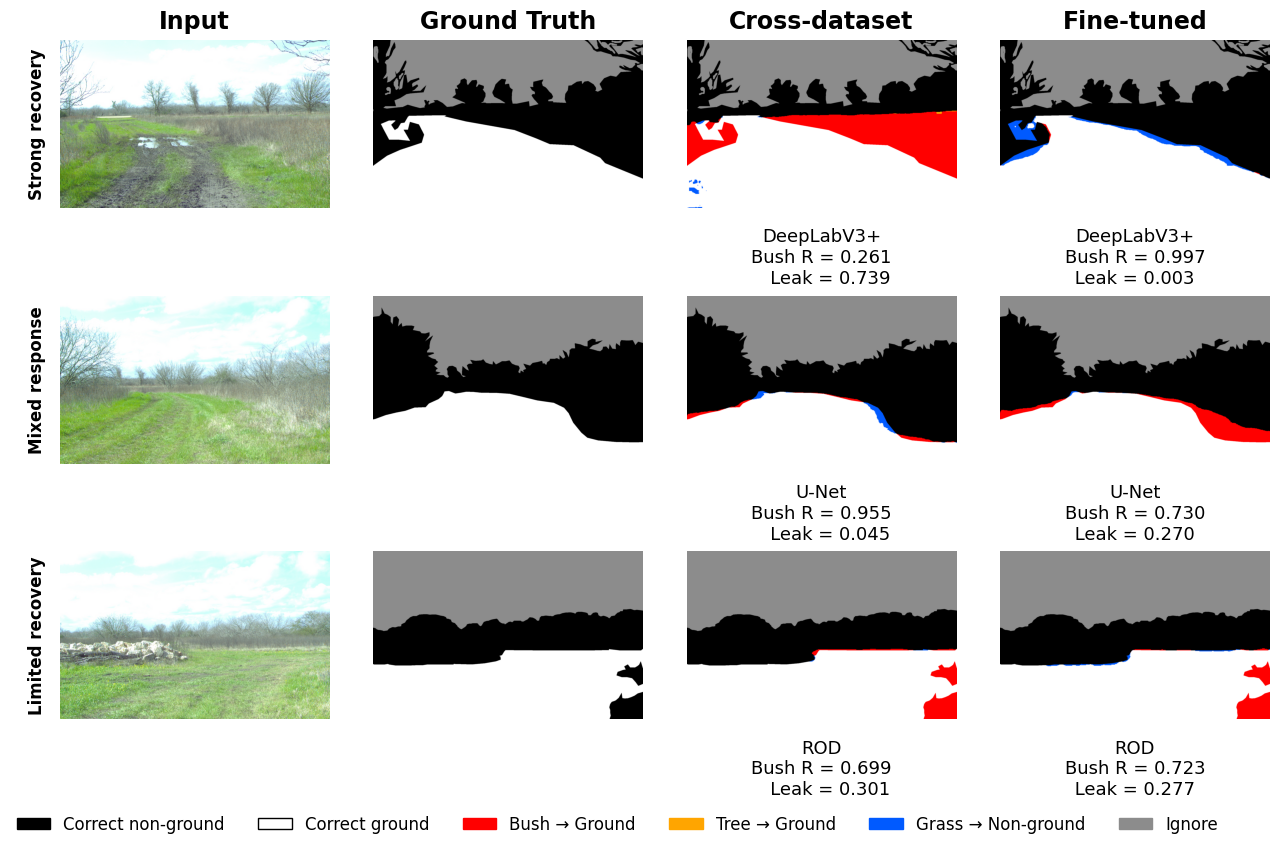

Saved figure:
/content/drive/MyDrive/IRP/05_vegetation_evaluation/03_rellis_finetuned/qualitative_before_after/rellis3d_vegetation_finetuning_qualitative.png


In [27]:
figure_rows = []

for _, row in selected.iterrows():
    processed_name = str(row["processed_name"])

    # ----------------------------------------------------------
    # Recover RGB and binary GT using the ORIGINAL experiment key:
    # (sequence, stem).
    #
    # processed_name is the prediction filename and therefore
    # intentionally contains an extra sequence prefix.
    # ----------------------------------------------------------

    sequence_key = normalise_sequence(row["sequence"])
    stem_key = str(row["stem"])

    manifest_key = (
        sequence_key,
        stem_key,
    )

    if manifest_key not in manifest_lookup:
        # Diagnostic information if a CSV from a different dataset
        # split/version is accidentally mixed in.
        same_stem = test_manifest_df[
            test_manifest_df["stem"].astype(str) == stem_key
        ]

        same_sequence = test_manifest_df[
            test_manifest_df["sequence_norm"].astype(str) == sequence_key
        ]

        print("FAILED KEY:", manifest_key)
        print("processed_name:", processed_name)
        print("Rows with same stem:", len(same_stem))
        print("Rows with same sequence:", len(same_sequence))

        if len(same_stem):
            display(
                same_stem[
                    [
                        "sequence_norm",
                        "stem",
                        "image_path_resolved",
                        "mask_path_resolved",
                    ]
                ].head(10)
            )

        raise FileNotFoundError(
            "Could not map selected vegetation result back to the "
            "current RELLIS test manifest using "
            f"(sequence, stem)={manifest_key}"
        )

    manifest_row = manifest_lookup[manifest_key]

    image_path = Path(
        manifest_row["image_path_resolved"]
    )

    mask_path = Path(
        manifest_row["mask_path_resolved"]
    )

    if not image_path.exists():
        raise FileNotFoundError(
            f"Resolved RGB file does not exist: {image_path}"
        )

    if not mask_path.exists():
        raise FileNotFoundError(
            f"Resolved binary GT does not exist: {mask_path}"
        )

    rgb = np.array(Image.open(image_path).convert("RGB"))
    target_shape = rgb.shape[:2]

    gt = resize_nearest(
        load_binary_mask(mask_path),
        target_shape,
    )

    if (
        source_mask_col_manifest is not None
        and pd.notna(manifest_row[source_mask_col_manifest])
    ):
        source_semantic_mask = manifest_row[source_mask_col_manifest]
    else:
        source_semantic_mask = (
            row["source_semantic_mask_after"]
            if pd.notna(row["source_semantic_mask_after"])
            else row["source_semantic_mask_before"]
        )

    semantic_rgb = read_raw_semantic_label(
        source_semantic_mask
    )

    semantic_rgb = cv2.resize(
        semantic_rgb,
        (target_shape[1], target_shape[0]),
        interpolation=cv2.INTER_NEAREST,
    )

    regions = extract_vegetation_regions(
        semantic_rgb
    )

    model_name = str(row["model"])

    pred_before = load_prediction(
        CROSS_PRED_ROOT,
        model_name,
        row["processed_name"],
        target_shape,
    )

    pred_after = load_prediction(
        FINETUNE_PRED_ROOT,
        model_name,
        row["processed_name"],
        target_shape,
    )

    figure_rows.append(
        {
            "case_name": row["case_name"],
            "model": model_name,
            "processed_name": row["processed_name"],
            "rgb": rgb,
            "gt": gt,
            "cross_map": make_vegetation_error_map(
                pred_before, gt, regions
            ),
            "finetuned_map": make_vegetation_error_map(
                pred_after, gt, regions
            ),
            "bush_before": float(
                row["bush_non_ground_recall_before"]
            ),
            "bush_after": float(
                row["bush_non_ground_recall_after"]
            ),
            "leak_before": float(
                row["bush_ground_leakage_before"]
            ),
            "leak_after": float(
                row["bush_ground_leakage_after"]
            ),
        }
    )

fig, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(13.5, 8.6),
)

column_titles = [
    "Input",
    "Ground Truth",
    "Cross-dataset",
    "Fine-tuned",
]

for c, title in enumerate(column_titles):
    axes[0, c].set_title(
        title,
        fontsize=17,
        fontweight="bold",
        pad=8,
    )

for r, info in enumerate(figure_rows):
    axes[r, 0].imshow(info["rgb"])
    axes[r, 1].imshow(make_binary_gt_display(info["gt"]))
    axes[r, 2].imshow(info["cross_map"])
    axes[r, 3].imshow(info["finetuned_map"])

    axes[r, 2].set_xlabel(
        (
            f"{info['model']}\n"
            f"Bush R = {info['bush_before']:.3f}\n   "
            f"Leak = {info['leak_before']:.3f}"
        ),
        fontsize=13,

    )
    axes[r, 2].xaxis.set_label_coords(
      0.5, -0.12
    )


    delta_bush = info["bush_after"] - info["bush_before"]
    delta_leak = info["leak_after"] - info["leak_before"]

    axes[r, 3].set_xlabel(
        (
            f"{info['model']}\n"
            f"Bush R = {info['bush_after']:.3f}\n "

            f"Leak = {info['leak_after']:.3f} "

        ),
        fontsize=13,

    )
    axes[r, 3].xaxis.set_label_coords(
      0.5, -0.12
    )

    axes[r, 0].set_ylabel(
        info["case_name"],
        fontsize=12,
        fontweight="bold",
        labelpad=10,
    )

    for c in range(4):
        axes[r, c].set_xticks([])
        axes[r, c].set_yticks([])

        for spine in axes[r, c].spines.values():
            spine.set_visible(False)

legend_handles = [
    mpatches.Patch(
        facecolor="black",
        edgecolor="black",
        label="Correct non-ground",
    ),
    mpatches.Patch(
        facecolor="white",
        edgecolor="black",
        label="Correct ground",
    ),
    mpatches.Patch(
        facecolor="red",
        edgecolor="red",
        label="Bush → Ground",
    ),
    mpatches.Patch(
        facecolor="orange",
        edgecolor="orange",
        label="Tree → Ground",
    ),
    mpatches.Patch(
        facecolor=(0 / 255, 90 / 255, 255 / 255),
        edgecolor=(0 / 255, 90 / 255, 255 / 255),
        label="Grass → Non-ground",
    ),
    mpatches.Patch(
        facecolor="0.55",
        edgecolor="0.55",
        label="Ignore",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=6,
    frameon=False,
    fontsize=12,
    bbox_to_anchor=(0.5, 0.00001),
)

plt.subplots_adjust(
    left=0.075,
    right=0.995,
    top=0.94,
    bottom=0.15,
    wspace=0.04,
    hspace=0.52,
)

plt.savefig(
    FIG_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(FIG_PATH)


## Optional manual override

If the automatic ranking selects a visually unhelpful frame, replace `selected` after the selection cell with manually chosen model/frame pairs from `paired`, then rerun the figure cell.

The code intentionally keeps the same visual language as the earlier overall fine-tuning qualitative figure, while changing the highlighted errors and metrics to vegetation-specific ones.
